# Оценка качества данных: очистка датасета «Титаник»

## 1. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.grid'] = True

RANDOM_STATE = 42

def make_model():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    )

In [2]:
raw = pd.read_csv('train.csv')
print('Размер датасета:', raw.shape)
raw.head()

Размер датасета: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. Базовая модель на «сырых» данных

In [4]:
cat_cols = raw.select_dtypes(include=['object', 'string']).columns.tolist()
print('Категориальные признаки (удаляем):', cat_cols)

base_df = (raw
           .drop(columns=cat_cols)      # убираем категориальные
           .drop(columns=['PassengerId'])  # убираем идентификатор
           .dropna())                   # убираем строки с пропусками

print('Оставшиеся признаки:', [c for c in base_df.columns if c != 'Survived'])
print('Строк осталось:', len(base_df), 'из', len(raw))

Категориальные признаки (удаляем): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Оставшиеся признаки: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Строк осталось: 714 из 891


In [5]:
X_base = base_df.drop(columns='Survived')
y_base = base_df['Survived']

Xtr, Xte, ytr, yte = train_test_split(
    X_base, y_base, test_size=0.2, random_state=RANDOM_STATE, stratify=y_base)

model_base = make_model().fit(Xtr, ytr)
acc_base = accuracy_score(yte, model_base.predict(Xte))

print(f'Accuracy (сырые данные): {acc_base:.4f}')

Accuracy (сырые данные): 0.7063


Базовая модель использует лишь `Pclass, Age, SibSp, Parch, Fare`. Из-за удаления категориальных мы **потеряли `Sex`** — а это, как известно, сильнейший предиктор выживания на «Титанике». Именно поэтому качество здесь ограничено. Дальше исправим это грамотной обработкой.

## 3. Повторная загрузка полных данных

In [6]:
df = pd.read_csv('train.csv')
print('Загружены полные данные:', df.shape)

Загружены полные данные: (891, 12)


## 4. Удаление логически ненужных признаков

Убираем признаки, которые не несут полезной информации для предсказания выживания:

- **`PassengerId`** — сквозной идентификатор, не связан с выживанием.
- **`Name`** — уникален для каждого пассажира (891 значение); как есть непригоден для модели. *(Из имени можно было бы извлечь титул — Mr/Mrs/Miss — но это выходит за рамки минимальной обработки.)*
- **`Ticket`** — 681 уникальное значение, слабоструктурированный код без явной предсказательной ценности.
- **`Cabin`** — 77% пропусков; данных слишком мало для надёжного использования. *(Можно было бы извлечь букву палубы, но при таком проценте пропусков это ненадёжно.)*

Признаки `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked` оставляем.

In [7]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
print('Осталось признаков:', list(df.columns))

Осталось признаков: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## 5. Обработка пропущенных значений

In [8]:
miss = df.isnull().sum()
print('Пропуски по столбцам:')
print(miss[miss > 0])

Пропуски по столбцам:
Age         177
Embarked      2
dtype: int64


### 5a. Сколько данных потеряем при простом удалении пропусков

Оценим потерю строк, если бы мы просто удалили все строки с пропусками — сначала на **полных исходных данных** (со всеми столбцами), затем на **рабочем наборе** (после удаления `Cabin`).

In [9]:
rows_full = raw.shape[0]
rows_after_dropna_full = raw.dropna().shape[0]
lost_full = 100 * (1 - rows_after_dropna_full / rows_full)

rows_after_dropna_work = df.dropna().shape[0]
lost_work = 100 * (1 - rows_after_dropna_work / len(df))

print(f'Полные данные: dropna оставит {rows_after_dropna_full} из {rows_full} строк '
      f'-> потеря {lost_full:.1f}%')
print(f'Рабочий набор (без Cabin): dropna оставит {rows_after_dropna_work} из {len(df)} строк '
      f'-> потеря {lost_work:.1f}%')

Полные данные: dropna оставит 183 из 891 строк -> потеря 79.5%
Рабочий набор (без Cabin): dropna оставит 712 из 891 строк -> потеря 20.1%


Простое удаление пропусков на полных данных уничтожило бы ~**80%** выборки (виноват `Cabin` с 77% пропусков). Даже после удаления `Cabin` мы потеряли бы ~**20%** строк из-за `Age`. Это неприемлемо — пропуски нужно **заполнять**, а не удалять.

### 5b. Заполнение пропусков подходящими методами

Для разных признаков — свой метод:

- **`Age`** (числовой, ~20% пропусков) — заполняем **медианой**. Медиана устойчива к скошенности и выбросам возраста (среднее сместилось бы). Дополнительно создаём бинарный признак **`Age_missing`** — это метод *«класс, указывающий на то, что значение было пропущено»*: сам факт отсутствия возраста может быть информативен.
- **`Embarked`** (категориальный, 2 пропуска) — заполняем **модой** (`'S'` — самый частый порт). Пропусков крайне мало, мода — естественный «константный» выбор для категории.

(Методы «случайное число» и «среднее» здесь менее уместны: случайное заполнение внесло бы шум, а медиана надёжнее среднего для скошенного `Age`.)

In [10]:
# Age: индикатор пропуска + заполнение медианой
df['Age_missing'] = df['Age'].isnull().astype(int)
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# Embarked: заполнение модой
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

print(f'Age заполнен медианой = {age_median}')
print(f'Embarked заполнен модой = {embarked_mode!r}')
print('Осталось пропусков:', int(df.isnull().sum().sum()))

Age заполнен медианой = 28.0
Embarked заполнен модой = 'S'
Осталось пропусков: 0


### Снимок «читаемых» данных для графиков

In [11]:
df_readable = df.copy()

## 6. Кодирование категориальных признаков в числовые

Признаки `Sex` и `Embarked` переводим в числа через `pd.get_dummies` (без циклов). Параметр `drop_first=True` убирает избыточный столбец (dummy-ловушка). `Pclass` оставляем как есть — это уже числовой порядковый признак (1 < 2 < 3).

In [12]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print('Признаки после кодирования:')
print(list(df.columns))
df.head()

Признаки после кодирования:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_missing', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Age,SibSp,Parch,Fare,Age_missing,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,True,False,True
1,1,1,38.0,1,0,71.2833,0,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True
3,1,1,35.0,1,0,53.1000,0,False,False,True
4,0,3,35.0,0,0,8.0500,0,True,False,True


## 7. Проверка и обработка выбросов

Смотрим на числовые признаки `Age` и `Fare` через диаграммы размаха (boxplot) и правило межквартильного размаха (IQR).

/tmp/ipykernel_14371/3208601003.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df['Age'], vert=True)
/tmp/ipykernel_14371/3208601003.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['Fare'], vert=True)


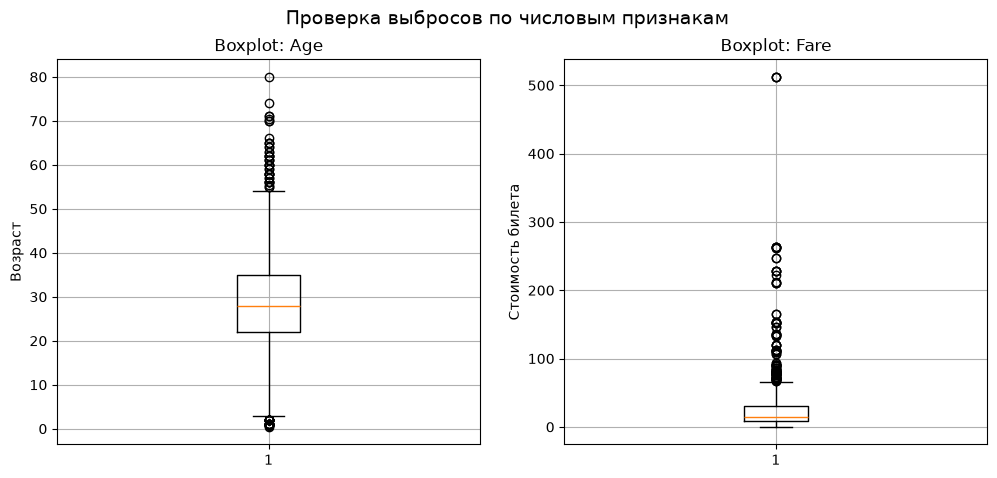

Age: верхняя граница IQR = 54.5, выбросов сверху = 42
Fare: верхняя граница IQR = 65.6, выбросов сверху = 116


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df['Age'], vert=True)
axes[0].set_title('Boxplot: Age')
axes[0].set_ylabel('Возраст')
axes[1].boxplot(df['Fare'], vert=True)
axes[1].set_title('Boxplot: Fare')
axes[1].set_ylabel('Стоимость билета')
plt.suptitle('Проверка выбросов по числовым признакам', fontsize=14)
plt.show()

for col in ['Age', 'Fare']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    hi = q3 + 1.5 * iqr
    n_out = (df[col] > hi).sum()
    print(f'{col}: верхняя граница IQR = {hi:.1f}, выбросов сверху = {n_out}')

### Решение по выбросам (обоснование)

- **`Age`** — значения в разумных пределах (0.42–80 лет), грубых выбросов-ошибок нет. Оставляем как есть.
- **`Fare`** — сильно скошен вправо, по IQR формально много «выбросов» (до 512). Но это **реальные пассажиры 1-го класса**, а не ошибки ввода, и высокая цена билета коррелирует с выживанием. Удалять такие строки нельзя — потеряем полезный сигнал.

Поэтому строки **не удаляем**, а применяем к `Fare` **логарифмическое преобразование** `log1p` — оно сжимает «тяжёлый хвост» и снижает влияние экстремальных значений без потери данных.

In [14]:
df['Fare'] = np.log1p(df['Fare'])
df_readable['Fare_log'] = np.log1p(df_readable['Fare'])
print('Fare преобразован: log1p. Новый диапазон:',
      round(df['Fare'].min(), 2), '...', round(df['Fare'].max(), 2))

Fare преобразован: log1p. Новый диапазон: 0.0 ... 6.24


## 8. Полезные графики

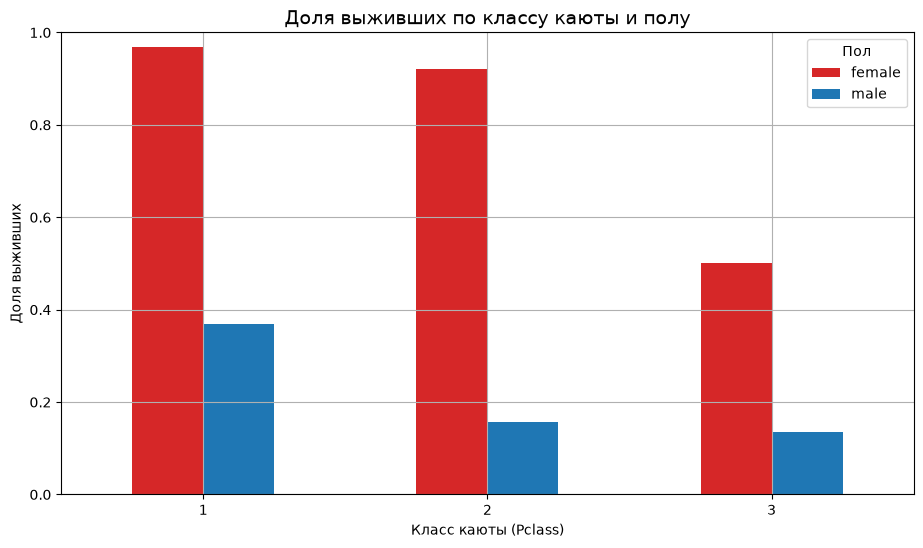

In [15]:
piv = df_readable.pivot_table(index='Pclass', columns='Sex',
                              values='Survived', aggfunc='mean')

ax = piv.plot(kind='bar', figsize=(11, 6),
              color={'female': 'tab:red', 'male': 'tab:blue'})
ax.set_title('Доля выживших по классу каюты и полу', fontsize=14)
ax.set_xlabel('Класс каюты (Pclass)')
ax.set_ylabel('Доля выживших')
ax.set_ylim(0, 1)
ax.legend(title='Пол')
plt.xticks(rotation=0)
plt.show()

**Вывод по графику 1:** пол — определяющий фактор: женщины выживали в разы чаще мужчин во всех классах. Класс каюты тоже важен — чем выше класс (меньше номер), тем выше шансы. Это подтверждает, что удаление `Sex` в базовой модели было главной причиной низкого качества.

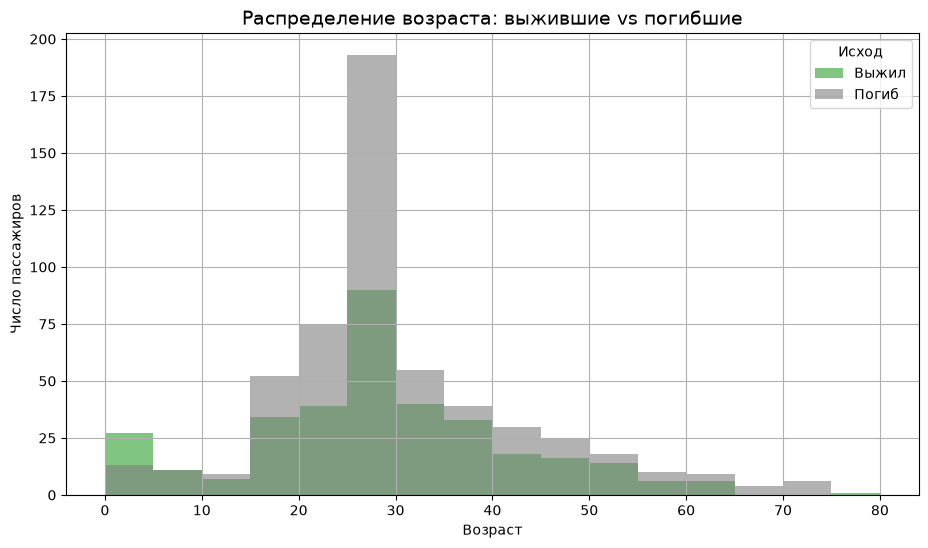

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(0, 80, 17)
ax.hist(df_readable.loc[df_readable['Survived'] == 1, 'Age'], bins=bins,
        alpha=0.6, label='Выжил', color='tab:green')
ax.hist(df_readable.loc[df_readable['Survived'] == 0, 'Age'], bins=bins,
        alpha=0.6, label='Погиб', color='tab:gray')
ax.set_title('Распределение возраста: выжившие vs погибшие', fontsize=14)
ax.set_xlabel('Возраст')
ax.set_ylabel('Число пассажиров')
ax.legend(title='Исход')
plt.show()

**Вывод по графику 2:** среди детей (примерно до 10 лет) доля выживших заметно выше — работал принцип «дети и женщины вперёд». В основной массе взрослых погибших больше. Зависимость выживания от возраста **нелинейна**, что мотивирует преобразование `Age` в следующем пункте.

## 9. Математическое преобразование признака `Age`

Так как связь возраста с выживанием нелинейна (дети выживали чаще), преобразуем `Age` **дискретизацией** — разобьём на возрастные группы с помощью `pd.cut`, затем закодируем их числовыми dummy-признаками. Это позволяет линейной модели «увидеть» нелинейный эффект возраста.

In [17]:
bins = [0, 12, 18, 35, 60, np.inf]
labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df = pd.get_dummies(df, columns=['AgeGroup'], drop_first=True)

print('Итоговый набор признаков:')
print(list(df.columns))

Итоговый набор признаков:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_missing', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'AgeGroup_Teen', 'AgeGroup_YoungAdult', 'AgeGroup_Adult', 'AgeGroup_Senior']


## 10. Обучение той же модели на преобразованных данных

In [18]:
X_clean = df.drop(columns='Survived')
y_clean = df['Survived']

Xtr, Xte, ytr, yte = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean)

model_clean = make_model().fit(Xtr, ytr)
acc_clean = accuracy_score(yte, model_clean.predict(Xte))

print(f'Accuracy после очистки данных: {acc_clean:.4f}')

Accuracy после очистки данных: 0.8045


In [ ]:
# Итоговое сравнение
compare = pd.DataFrame({
    'Модель': ['П.2 — сырые данные', 'П.10 — после очистки'],
    'Признаков': [X_base.shape[1], X_clean.shape[1]],
    'Строк в обучении': [len(X_base), len(X_clean)],
    'Accuracy': [round(acc_base, 4), round(acc_clean, 4)]
})
compare['Прирост'] = ['—', f'+{acc_clean - acc_base:.4f}']
compare

## 11. Выводы

### a) Какие преобразования сделаны и почему

- **Удалены неинформативные признаки** `PassengerId`, `Name`, `Ticket`, `Cabin` — идентификаторы и почти пустые/уникальные поля, не помогающие предсказанию.
- **Заполнены пропуски:** `Age` — медианой (устойчива к скошенности) плюс индикатор `Age_missing`; `Embarked` — модой. Это сохранило ~20–80% строк, которые потерялись бы при простом удалении.
- **Категориальные признаки закодированы** (`Sex`, `Embarked`) через `pd.get_dummies` — без них модель не может учиться на важнейшем факторе (поле).
- **Выбросы `Fare`** не удалены (это реальные пассажиры, а не ошибки), но признак прологарифмирован (`log1p`) для снижения влияния «хвоста».
- **`Age` преобразован** в возрастные группы (`pd.cut`), чтобы уловить нелинейный эффект (дети выживали чаще).

### b) Сравнение метрик п.2 и п.10

| Модель | Accuracy |
|---|---|
| Сырые данные (п.2) | **0.7063** |
| После очистки (п.10) | **0.8045** |

Качество выросло на **+0.0982** (≈ 9.8 п.п.) — точные числа см. в таблице сравнения выше. Главный вклад — возвращение признака `Sex`, который наивный подход выбрасывал вместе со всеми категориальными.

### c) О целесообразности работы с данными

Эксперимент наглядно показывает: **качество модели определяется в первую очередь качеством данных**, а не только алгоритмом. Одна и та же логистическая регрессия дала принципиально разный результат до и после обработки. Грамотный EDA — заполнение пропусков вместо их удаления, кодирование категорий, обработка выбросов и осмысленное конструирование признаков — часто даёт больший прирост, чем смена или тонкая настройка модели. Это неотъемлемый этап любого ML-проекта.

### * Нужно ли так же исследовать большие данные?

Да, принципы те же, но подход меняется: на действительно больших данных ручной анализ каждого признака невозможен, поэтому используют **автоматизированные пайплайны** (`sklearn.Pipeline`, `ColumnTransformer`), выборочный/распределённый анализ (Spark, Dask), профилирование данных и мониторинг качества. Пропуски, выбросы и утечки на больших данных не менее опасны — но обрабатываются программно и воспроизводимо, а не «вручную».